In [10]:
#Imports

from numba.cpython.unsafe.numbers import trailing_zeros
from sl_forgery.utils.dataclass import Data
from pathlib import Path

from plotly import graph_objects as go
from matplotlib import pyplot as plt # Delete

import numpy as np
import polars as pl


In [ ]:
# Function vars + global vars

project_root = Path(r"C:\Users\jacob\OneDrive\Desktop\PlaceFields\sl-forgery")
data = Data(project_root / "data")

bin_size = 5 #cm
track_length = 240
cue_length = 30
cue_positions = range(0, track_length, cue_length * 2) # *2 bc of the gray region

data = Data(project_root / "data")



In [ ]:
mouse, session, target_group, cell = 6, "2025-06-23-13-32-06-980761", "single_day", 11
# Process data
session_avg_df, sess_sem, result, trial_avg_df = data.process_data(mouse, session, target_group)


getting data
got data
grouping data
grouped data
normalizing data
normalized data
binning data


KeyboardInterrupt: 

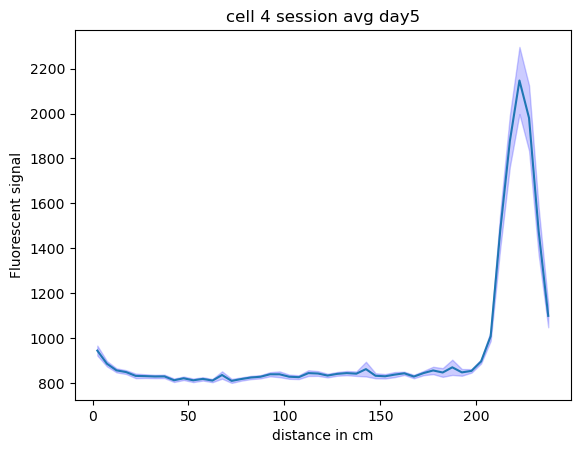

In [30]:
def plot_session_plotly(mouse, session, target_group, cell, data : Data):

    # %%%%%%%%%%%%%%%%%%
    # TODO normalize F --> F - .7Fneu for y axis OR z-score;  extract cue;  add option for single day or multi day
    #  plotting;  integrate with plotly when jacob is done;  plot cue regions under the graph; basically thick little
    #  vlines of different colors
    # TODO make this pull the column names for
    # cell ID

    session_avg_df, sess_sem, result, trial_avg_df = data.process_data(mouse, session, target_group)


    cell_val = session_avg_df['cell_{}_signal_binned'.format(cell)][-1]  # selects the last row of the col,
    # which has the avg session data

    mean = cell_val.to_numpy()  # , cell_val[1].to_numpy()    #extract mean array and sem array; again issue with
    # pulling ndarrays from polars df
    sem = sess_sem[cell] # Before Chelsea indexed sess_sem[0] every time, I think she meant to get the sem for the cell being plotted
    
    xaxis = np.arange(bin_size / 2, track_length, bin_size)  # plot the avg signal in center of bin
    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x = xaxis,
        y = mean,
        mode='lines',
        line=dict(width=3),
    ))

    upper = mean + sem
    lower = mean - sem

    fig.add_trace(go.Scatter(
        x=list(xaxis) + list(xaxis[::-1]),  # x followed by reversed x
        y=list(upper) + list(lower[::-1]),  # upper followed by reversed lower
        fill='toself',
        fillcolor='rgba(0, 0, 255, 0.2)',  # RGBA for transparency
        line=dict(color='rgba(255,255,255,0)'),  # No border
        hoverinfo='skip',
        name='Mean ± SEM'
    ))

    fig.show(renderer="browser")

    fig, ax = plt.subplots()
    ax.plot(xaxis, mean)
    plt.fill_between(xaxis, mean - sem, mean + sem,
                        color='blue', alpha=0.2, label='Mean +/- SEM')

    plt.title("cell {} session avg day5".format(cell))
    plt.xlabel("distance in cm")
    plt.ylabel("Fluorescent signal")

def plot_session(mouse, session, target_group, cell, data : Data):

    # %%%%%%%%%%%%%%%%%%
    # TODO normalize F --> F - .7Fneu for y axis OR z-score;  extract cue;  add option for single day or multi day
    #  plotting;  integrate with plotly when jacob is done;  plot cue regions under the graph; basically thick little
    #  vlines of different colors
    # TODO make this pull the column names for
    # cell ID

    session_avg_df, sess_sem, result, trial_avg_df = data.process_data(mouse, session, target_group)


    cell_val = session_avg_df['cell_{}_signal_binned'.format(cell)][-1]  # selects the last row of the col,
    # which has the avg session data

    mean = cell_val.to_numpy()  # , cell_val[1].to_numpy()    #extract mean array and sem array; again issue with
    # pulling ndarrays from polars df
    sem = sess_sem[cell] # Before Chelsea indexed sess_sem[0] every time, I think she meant to get the sem for the cell being plotted
    
    
    fig, ax = plt.subplots()
    xaxis = np.arange(bin_size / 2, track_length, bin_size)  # plot the avg signal in center of bin
    ax.plot(xaxis, mean)
    plt.fill_between(xaxis, mean - sem, mean + sem,
                        color='blue', alpha=0.2, label='Mean +/- SEM')

    plt.title("cell {} session avg day5".format(cell))
    plt.xlabel("distance in cm")
    plt.ylabel("Fluorescent signal")

def plot_session_trials(mouse, session, target_group, cell, data : Data):

    # %%%%%%%%%%%%%%%%%%
    # TODO normalize F --> F - .7Fneu for y axis OR z-score;  extract cue;  add option for single day or multi day
    #  plotting;  integrate with plotly when jacob is done;  plot cue regions under the graph; basically thick little
    #  vlines of different colors
    # TODO make this pull the column names for
    # cell ID

    session_avg_df, sess_sem, result, trial_avg_df = data.process_data(mouse, session, target_group)

    cell_val = session_avg_df['cell_{}_signal_binned'.format(cell)][-1]  # selects the last row of the col,
    # which has the avg session data

    mean = cell_val.to_numpy()  # , cell_val[1].to_numpy()    #extract mean array and sem array; again issue with
    # pulling ndarrays from polars df
    sem = sess_sem[cell] # Before Chelsea indexed sess_sem[0] every time, I think she meant to get the sem for the cell being plotted
    
    xaxis = np.arange(bin_size / 2, track_length, bin_size)  # plot the avg signal in center of bin

    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x = xaxis,
        y = mean,
        mode='lines',
        line=dict(width=3),
        name="Mean"
    ))

    upper = mean + sem
    lower = mean - sem

    fig.add_trace(go.Scatter(
        x=list(xaxis) + list(xaxis[::-1]),  # x followed by reversed x
        y=list(upper) + list(lower[::-1]),  # upper followed by reversed lower
        fill='toself',
        fillcolor='rgba(0, 0, 255, 0.2)',  # RGBA for transparency
        line=dict(color='rgba(255,255,255,0)'),  # No border
        hoverinfo='skip',
        name='SEM'
    ))

    trial_traces = [go.Scatter(
        x = xaxis,
        y = trial_avg_df[i, cell],
        mode='lines',
        line=dict(width=2),
        name=f"Trial {i+1}",
        visible=False,
    ) for i in range(result.shape[0])]

    fig.add_traces(trial_traces)

    fig.update_layout(
        title=dict(
            text=f"Cell Fluorescence Trial Averages",
            x=.5,
        ),
        plot_bgcolor='white',
        xaxis=dict(
            title="Track position (cm)",
            range=[0, track_length]
        ),
        yaxis=dict(
            title="Flourescant Signal",
            range=[0, 6000]
        ),
        updatemenus=[dict(
            type="dropdown",
            xanchor="left", yanchor="bottom",
            x=1, y=1,
            direction="down",
            buttons=[
                dict(
                    label="Session Average",
                    method="update",
                    args=[{"visible": [True] * 2 + [False] * len(trial_traces)}]
                ),
                dict(
                    label="Trial Binned Averages",
                    method="update",
                    args=[{"visible": [False] * 2 + [True] * len(trial_traces)}]
                ),
            ]
        )],
        annotations=
        [
            *[
                dict(
                    text=f"Cue {i+1}",
                    xref="x", yref="paper",
                    x=pos + cue_length / 2, y=1, 
                    xanchor="center", yanchor="top",
                    align="center", 
                    showarrow=False,
                ) for i, pos in enumerate(cue_positions)          
            ],
            dict(
                text=f"Mouse: {mouse}<br>Session: {Data.parse_session(session)}<br>Cell: {cell}",
                xref="paper", yref="paper",
                x=1, y=1, 
                xanchor="right", yanchor="bottom",
                align="left", 
                showarrow=False,
            )
        ],
        shapes=[
            dict(type="rect", x0=pos, x1=pos+cue_length, y0=0, y1=1, xref="x", yref="paper",
                fillcolor="lightsteelblue", opacity=0.4, layer="below", line_width=0) 
            for pos in cue_positions
        ],
    )
    fig.show(renderer="browser")

# plot_session_plotly(6, "2025-06-23-13-32-06-980761", "single_day", cell, data)
plot_session_plotly(6, "2025-06-23-13-32-06-980761", "single_day", cell, data)
plot_session_trials(6, "2025-06-23-13-32-06-980761", "single_day", cell, data)


